In [1]:
import os
import matplotlib.pyplot as plt
from notebooks.visualization.activations_funcs import get_activation_dictionnary
from notebooks.visualization.random_networks_plots.plot_config import apply_plot_style
from notebooks.visualization.activations_funcs import get_all_connections
from paths import PROJECT_ROOT
plots_dir = os.path.join(PROJECT_ROOT, "plots")
from notebooks.visualization.random_networks_plots.plot_config import RANDOMIZATION_NAMES
NUM_PASSES = 3

apply_plot_style()

# Create plots directory if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)


from utils.helpers import load_neuron_coordinates

from joblib import Memory


cache_dir = os.path.join(PROJECT_ROOT, "notebooks", "visualization", "data", ".joblib_cache")
memory = Memory(location=cache_dir, verbose=0)


@memory.cache
def connections_cached():
    """Disk-cached version of get_all_connections()."""
    return get_all_connections()


@memory.cache
def activations_cached(num_passes: int = 4):
    """Disk-cached wrapper around get_activation_dictionnary()."""
    conn_dict = connections_cached()
    return get_activation_dictionnary(conn_dict, num_passes)

neuron_position_data = load_neuron_coordinates()

# Heavy cached computations
connections_dict = connections_cached()
activations_dict = activations_cached(NUM_PASSES)

# remove random pruned from both
connections_dict.pop(RANDOMIZATION_NAMES["random_pruned"])
activations_dict.pop(RANDOMIZATION_NAMES["random_pruned"])

Changed working directory to c:\Users\eudald\Desktop\doctorat\codi\connectome
Project root: c:\Users\eudald\Desktop\doctorat\codi\connectome


,root_id,input,activation_1,activation_2,activation_3
0,720575940596125868,0.0,0.0,0.000000,54.847743
1,720575940597856265,0.0,0.0,4.662577,-229.172382
2,720575940597944841,0.0,0.0,-2.992619,-231.093259
3,720575940598267657,0.0,0.0,10.665208,-748.561821
4,720575940599333574,0.0,0.0,-1.005776,-90.591939
...,...,...,...,...,...
138634,720575940622742286,0.0,0.0,0.000000,0.000000
138635,720575940629719811,0.0,0.0,0.000000,1.442132
138636,720575940639046372,0.0,0.0,0.000000,-0.822484
138637,720575940633284895,0.0,0.0,0.000000,-0.254070


C:\Users\eudald\AppData\Local\Temp\ipykernel_2692\2604650915.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


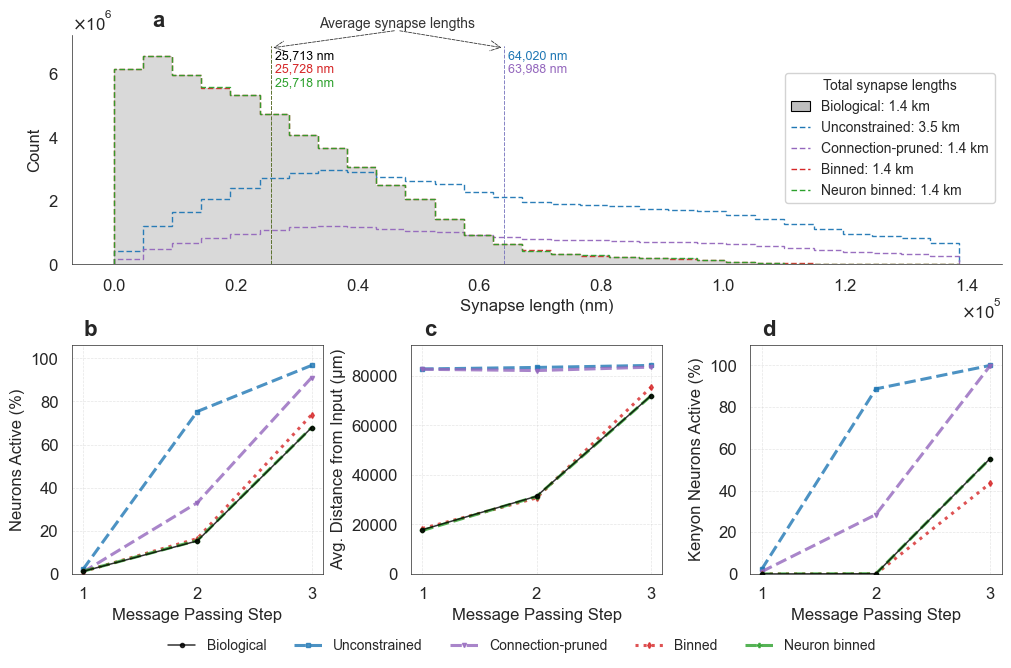

In [20]:
import importlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.close('all')

from notebooks.visualization.random_networks_plots import synapse_distributions
from notebooks.visualization.random_networks_plots import activation_plots
importlib.reload(synapse_distributions)
importlib.reload(activation_plots)
from notebooks.visualization.random_networks_plots.synapse_distributions import plot_overlay_wiring_distributions
from notebooks.visualization.random_networks_plots.activation_plots import plot_activation_statistics

# Create combined figure with gridspec
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1, 1], hspace=0.35, wspace=0.35)

# Create axes
ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[1, 2])

# Panel a: Wiring distributions
plot_overlay_wiring_distributions(
    neuron_position_data, connections_dict,
    bins=30, use_density=False, font_size=10, show_mean_lines=True, ax=ax_a
)

# Panel b, c, d: Activation statistics
plot_activation_statistics(
    activations_dict, neuron_position_data, num_steps=3,
    axes=(ax_b, ax_c, ax_d), show_legend=False, show_title=False
)

# Panel labels (Nature style: lowercase, bold, top-left)
for ax, label in zip([ax_a, ax_b, ax_c, ax_d], ['a', 'b', 'c', 'd']):
    ax.text(0.1, 1.02, label, transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='bottom', ha='right')

# Single shared legend at bottom
handles, labels = ax_b.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=len(labels), fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# export to pdf
fig.savefig(os.path.join(plots_dir, "figure_2.pdf"), dpi=300)